# 8.1 Deep Learning — TensorFlow/Keras Inference

In [27]:
import os, sys
import tensorflow as tf
os.environ["KERAS_BACKEND"]="tensorflow"
import keras
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
tf.__version__

'2.19.0'

In [28]:
!wget https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/07_DeepLearning/car.jpg

--2026-04-04 16:50:19--  https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/07_DeepLearning/car.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60742 (59K) [image/jpeg]
Saving to: ‘car.jpg.1’

car.jpg.1           100%[===================>]  59.32K  --.-KB/s    in 0.01s   

2026-04-04 16:50:19 (4.57 MB/s) - ‘car.jpg.1’ saved [60742/60742]



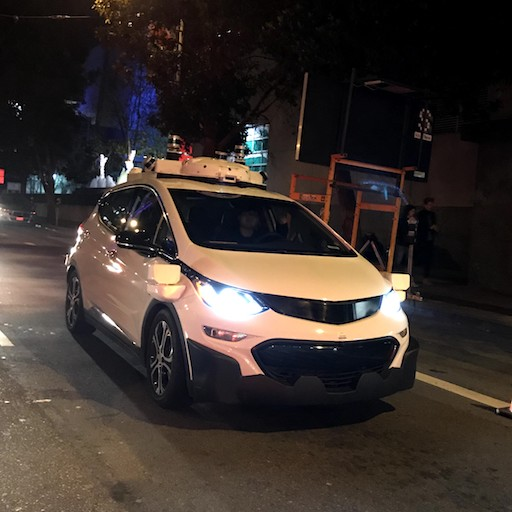

In [29]:
from IPython.display import Image
Image("car.jpg")

In [30]:

import time
# Load ResNet50 model with pretrained ImageNet weights
model_resnet = ResNet50(weights="imagenet")

# Path to image
img_path = "car.jpg"

# Load image and resize it to 224x224
img = image.load_img(img_path, target_size=(224, 224))

# Convert image to numpy array
x = image.img_to_array(img)

# Add extra dimension because model expects a batch
x = np.expand_dims(x, axis=0)

# Preprocess image for ResNet50
x = preprocess_input(x)

# Warm-up runs to avoid measuring one time setup overhead
# Warm‑ups were added once I recognized that the timing differed from run to run.
for _ in range(3):
    _ = model_resnet.predict(x, verbose=0)



#Since the timing variation still wasn’t resolved, I decided to measure ten runs and report the average to reduce the differences.
#This was part of the experimentation and learning process, and I wanted to share it to illustrate the variation.
# Run prediction
times = []

for i in range(10):
    start = time.time()
    preds = model_resnet.predict(x, verbose=0)
    end = time.time()
    times.append(end - start)
    print ("Run",i, "time =", end-start, "seconds")

# Show top 3 predicted classes
print("ResNet50 predictions:")
print(decode_predictions(preds, top=3)[0])
print("ResNet50 Inference average time :", np.mean(times), "seconds")

Run 0 time = 0.18748688697814941 seconds
Run 1 time = 0.18915963172912598 seconds
Run 2 time = 0.18669724464416504 seconds
Run 3 time = 0.17858481407165527 seconds
Run 4 time = 0.16991114616394043 seconds
Run 5 time = 0.16180634498596191 seconds
Run 6 time = 0.16558361053466797 seconds
Run 7 time = 0.16205334663391113 seconds
Run 8 time = 0.16344976425170898 seconds
Run 9 time = 0.16948151588439941 seconds
ResNet50 predictions:
[('n03770679', 'minivan', np.float32(0.4097555)), ('n02930766', 'cab', np.float32(0.20739926)), ('n03670208', 'limousine', np.float32(0.13904025))]
ResNet50 Inference average time : 0.17342143058776854 seconds


In [31]:
from keras.applications.vgg16 import VGG16, preprocess_input as preprocess_vgg

# Load VGG16 model
model_vgg = VGG16(weights="imagenet")

# IMPORTANT: use SAME image, but new preprocessing
x_vgg = preprocess_vgg(x.copy())
# Warm-up runs to avoid measuring one time setup overhead
#
for _ in range(3):
    _ = model_vgg.predict(x, verbose=0)
# Run prediction
for i in range(10):
    start = time.time()
    preds = model_vgg.predict(x, verbose=0)
    end = time.time()
    times.append(end - start)
    print ("Run",i, "time =", end-start, "seconds")

# Show results
print("VGG16 predictions:")
print(decode_predictions(preds, top=3)[0])
print("VGG16 Inference time:", np.mean(times), "seconds")

Run 0 time = 0.43741273880004883 seconds
Run 1 time = 0.6598103046417236 seconds
Run 2 time = 0.6758701801300049 seconds
Run 3 time = 0.45580101013183594 seconds
Run 4 time = 0.43627429008483887 seconds
Run 5 time = 0.45356082916259766 seconds
Run 6 time = 0.6741869449615479 seconds
Run 7 time = 0.6634848117828369 seconds
Run 8 time = 0.4254624843597412 seconds
Run 9 time = 0.6638810634613037 seconds
VGG16 predictions:
[('n03770679', 'minivan', np.float32(0.7604537)), ('n02930766', 'cab', np.float32(0.0940978)), ('n03977966', 'police_van', np.float32(0.04767517))]
VGG16 Inference time: 0.36399794816970826 seconds


In [32]:
!wget https://upload.wikimedia.org/wikipedia/commons/5/5e/Sleeping_cat_on_her_back.jpg -O cat.jpg

--2026-04-04 16:50:43--  https://upload.wikimedia.org/wikipedia/commons/5/5e/Sleeping_cat_on_her_back.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1653479 (1.6M) [image/jpeg]
Saving to: ‘cat.jpg’

cat.jpg             100%[===================>]   1.58M  9.08MB/s    in 0.2s    

2026-04-04 16:50:44 (9.08 MB/s) - ‘cat.jpg’ saved [1653479/1653479]



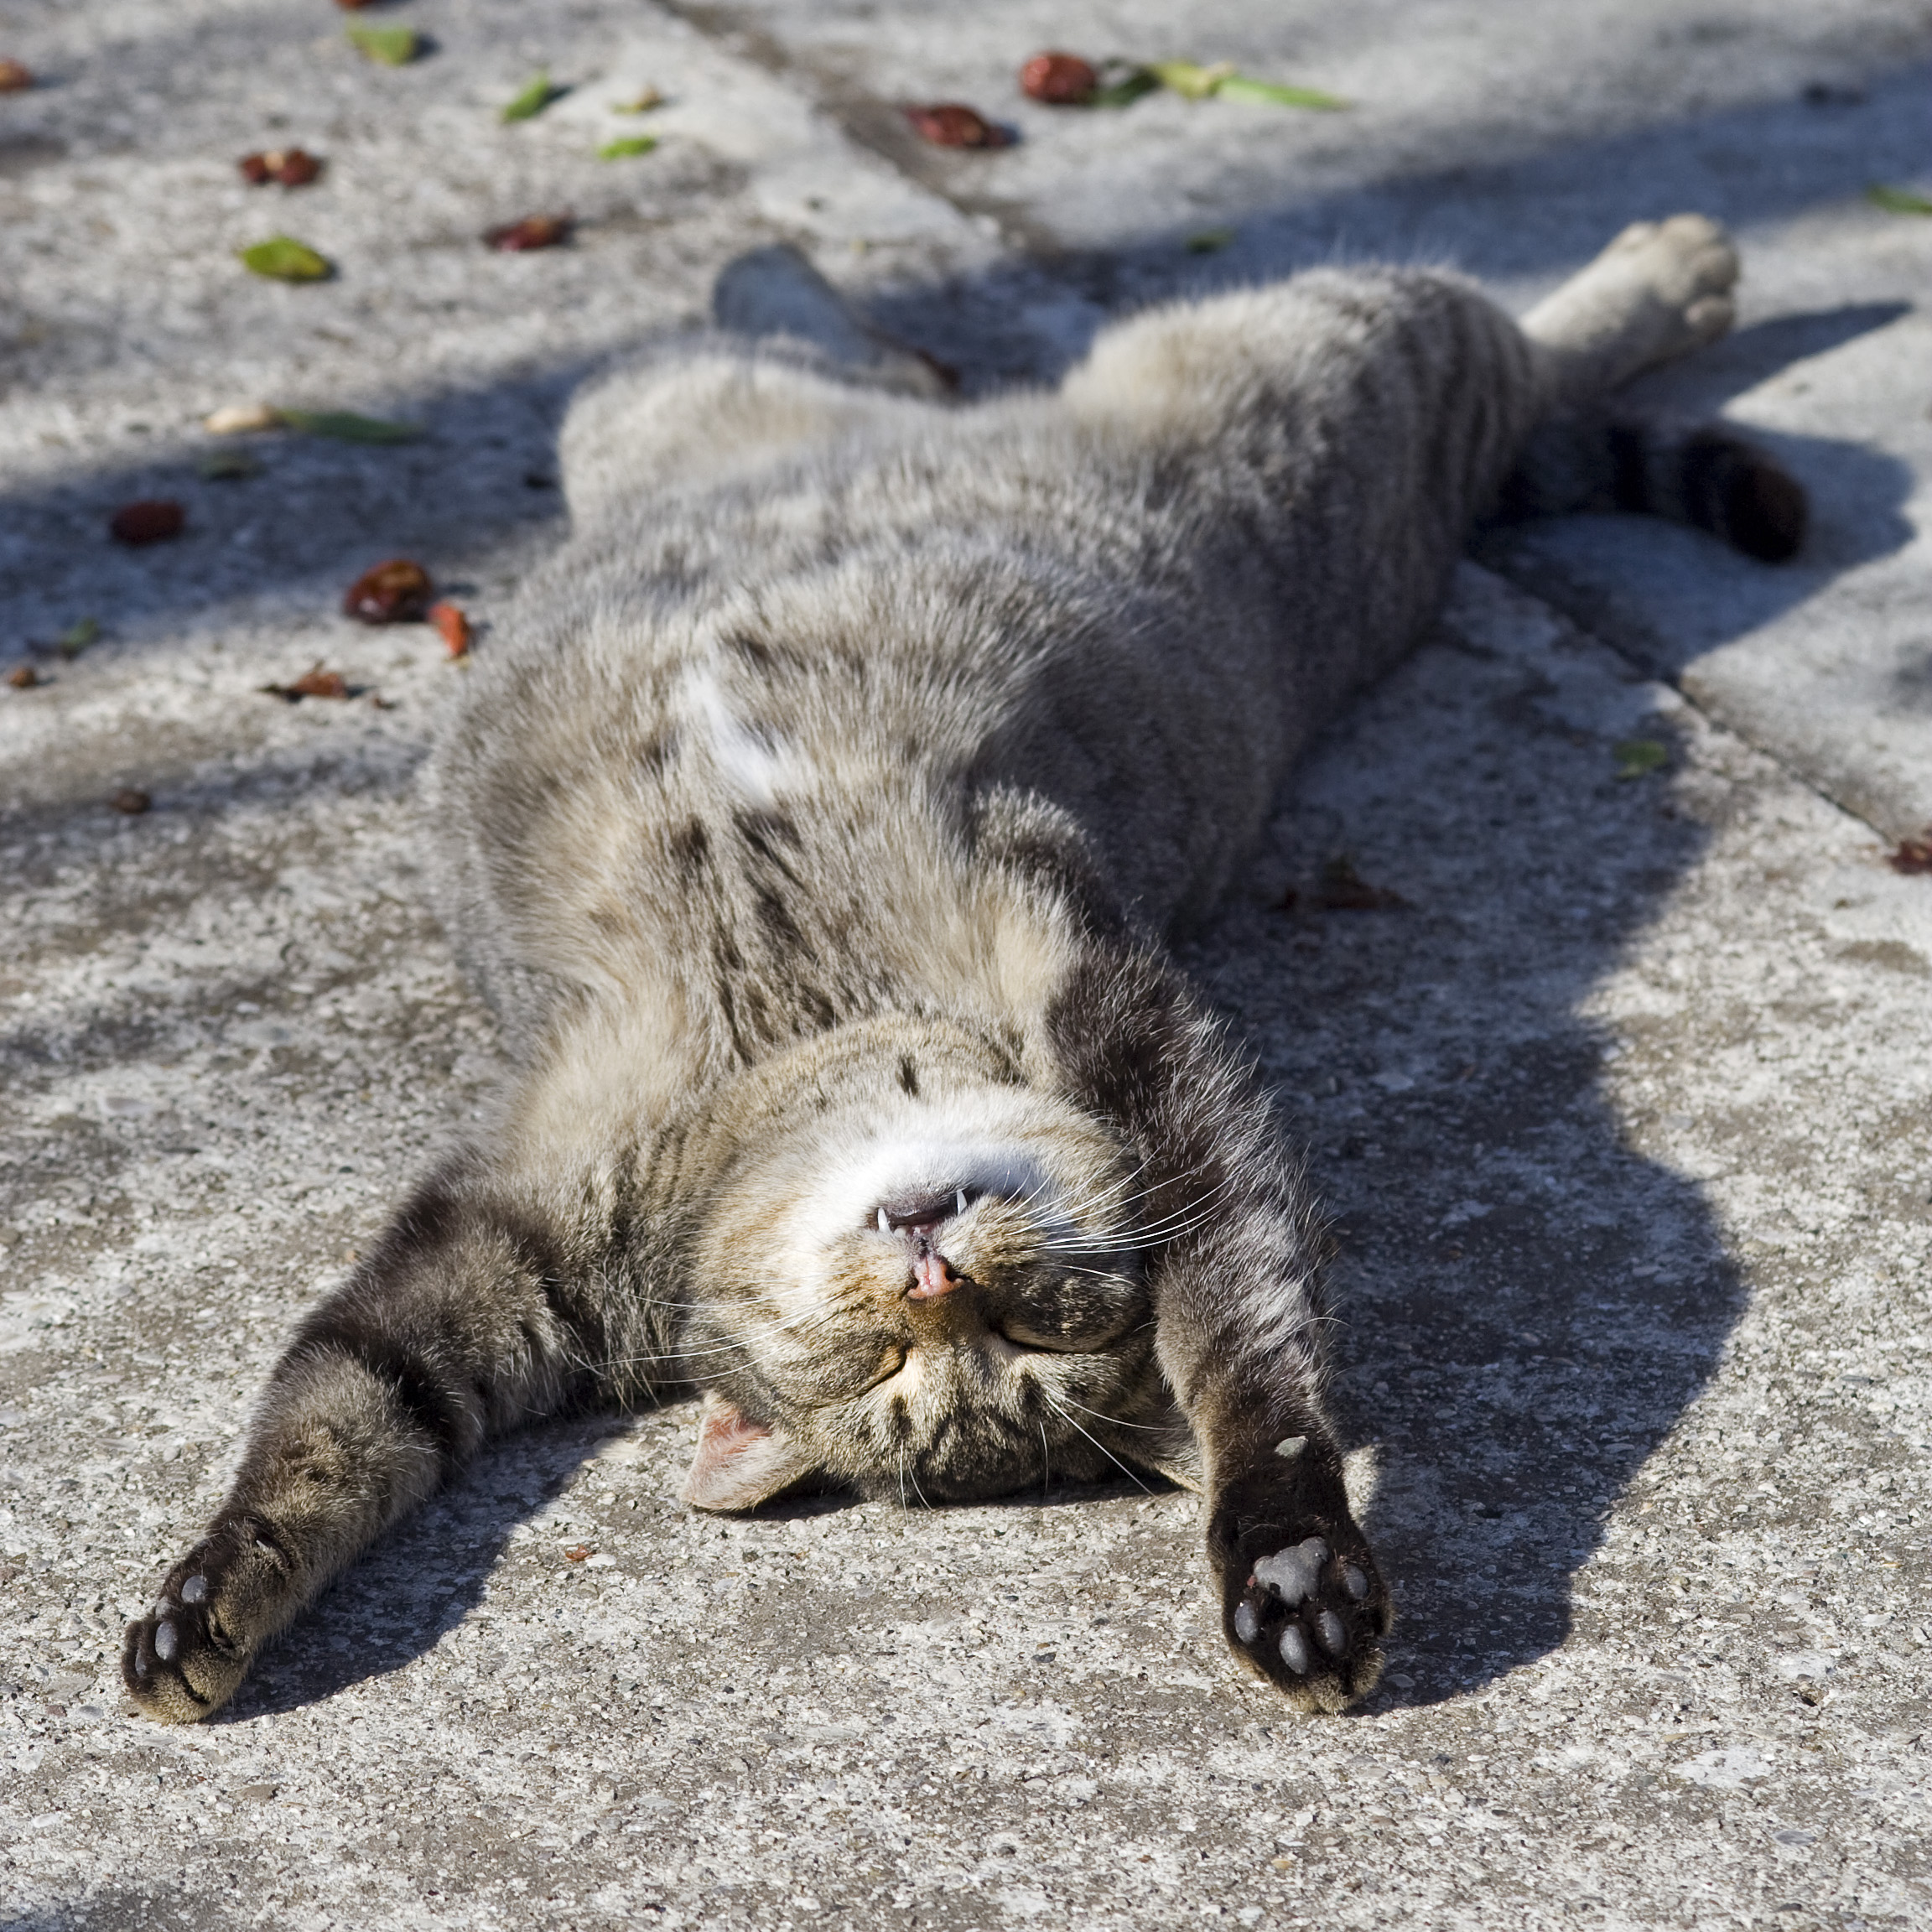

In [33]:
from IPython.display import Image
Image("cat.jpg")

In [35]:
# Load and preprocess the new image
img_path = "cat.jpg"

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# ResNet50 prediction
preds_resnet = model_resnet.predict(x, verbose=0)

# VGG16 prediction
preds_vgg = model_vgg.predict(x, verbose=0)

# Print results
print("ResNet prediction:", decode_predictions(preds_resnet, top=1))
print("VGG prediction:", decode_predictions(preds_vgg, top=1))

ResNet prediction: [[('n02123045', 'tabby', np.float32(0.3150846))]]
VGG prediction: [[('n02077923', 'sea_lion', np.float32(0.3108295))]]


Do note that the input image format for this model is different than for
the VGG16 and ResNet models (299x299 instead of 224x224),
and that the input preprocessing function
is also different (same as Inception V3).